<a href="https://colab.research.google.com/github/mazzeratziii/Predicting-the-secondary-structure-of-proteins/blob/main/Biotech_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Предсказание вторичной структуры белков на основе аминокислотной последовательности с использованием методов машинного обучения

In [ ]:
!pip install biopython scikit-learn seaborn transformers torch xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from collections import Counter
from transformers import AutoTokenizer, AutoModel
import torch
import random

In [ ]:
# Загрузка и первичная обработка данных
df = pd.read_csv("/content/drive/MyDrive/ColabFiles/biotech_project/train.csv")
df = df[['seq', 'sst3']].dropna()
print("Размер датасета:", df.shape)


Размер датасета: (5534, 2)


In [ ]:
# Вычисление физико-химических признаков белков
def protein_features(sequence):
    try:
        analysis = ProteinAnalysis(sequence)
        return [
            analysis.molecular_weight(),
            analysis.aromaticity(),
            analysis.instability_index(),
            analysis.gravy(),
            analysis.isoelectric_point()
        ]
    except:
        return [np.nan]*5

features = df['seq'].apply(protein_features)
features_df = pd.DataFrame(features.tolist(),
                           columns=['molecular_weight','aromaticity','instability_index','gravy','isoelectric_point'])
df = pd.concat([df, features_df], axis=1)
df = df.dropna()


In [ ]:
# Создание целевой переменной 'target'
def get_dominant_ss_from_sst3(sst_sequence):
    if not isinstance(sst_sequence, str) or not sst_sequence:
        return np.nan
    valid_chars = [char for char in sst_sequence if char in ['C', 'H', 'E']]
    if not valid_chars:
        return np.nan
    counts = Counter(valid_chars)
    return max(counts, key=counts.get)

df['target'] = df['sst3'].apply(get_dominant_ss_from_sst3)
df.dropna(subset=['target'], inplace=True)
df.head()

,seq,sst3,molecular_weight,aromaticity,instability_index,gravy,isoelectric_point,target
1,RPESELIRQSWRVVSRSPLEHGTVLFARLFALEPSLLPLFQYNGRQ...,CCCHHHHHHHHHHHHCCHHHHHHHHHHHHHHHCHHHHHHCCECCEC...,16615.7038,0.094595,55.892568,-0.137162,6.348825,H
2,MKIAILGAGCYRTHAAAGITNFMRACEVAKEVGKPEIALTHSSITY...,CEEEEECCCCCHHHHHHCCCCCHHHHHHHHHHCCHHHHHCCHHHHH...,37066.8496,0.052326,28.167151,0.056686,5.473618,H
3,RRTVPRGTLRKIIKKHKPHLRLAANTDLLVHLSFLLFLHRLAEEAR...,CCCCCHHHHHHHHHHHCCCCCCCCCHHHHHHHHHHHHHHHHHHHHH...,8628.2536,0.040000,24.972000,-0.306667,11.341552,H
7,LLHKRVVLASASPRRQEILSNAGLRFEVVPSKFKEKLDKASFATPY...,CCCCCEEECCCCHHHHHHHHHCCCCCEECCCCCCCCCCHHHCCCHH...,22849.9723,0.093137,33.626520,-0.189216,7.217836,H
10,KLHEIKQELKDLFSHLPYKINKVEVSLYEPGVLLIDIDGEDSALLI...,CHHHHHHHHHHHCCCCCCCEEEEEEEEEECCEEEEEEEEHHHCCCC...,16763.3276,0.103448,20.722069,-0.212414,8.635427,H


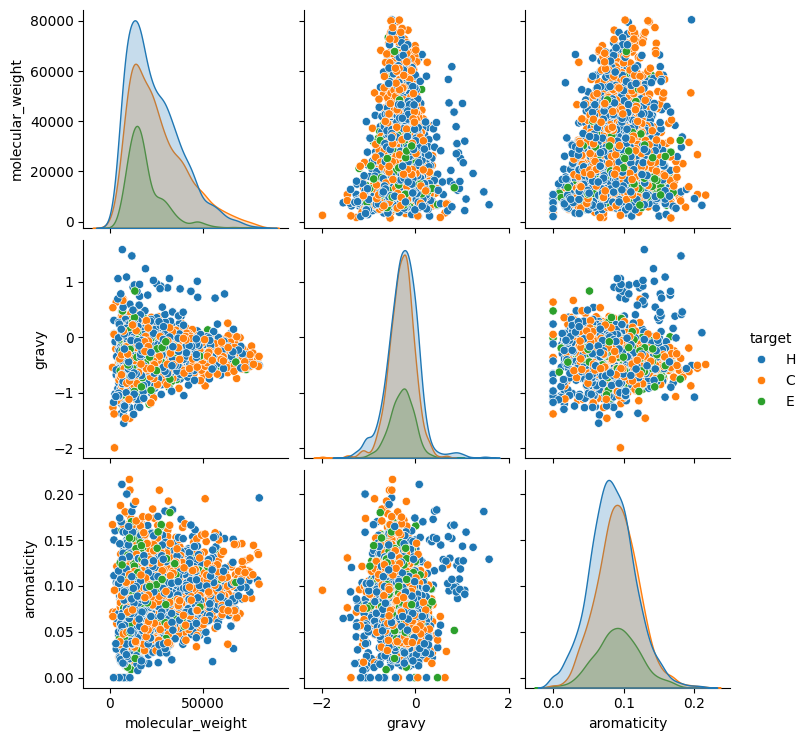

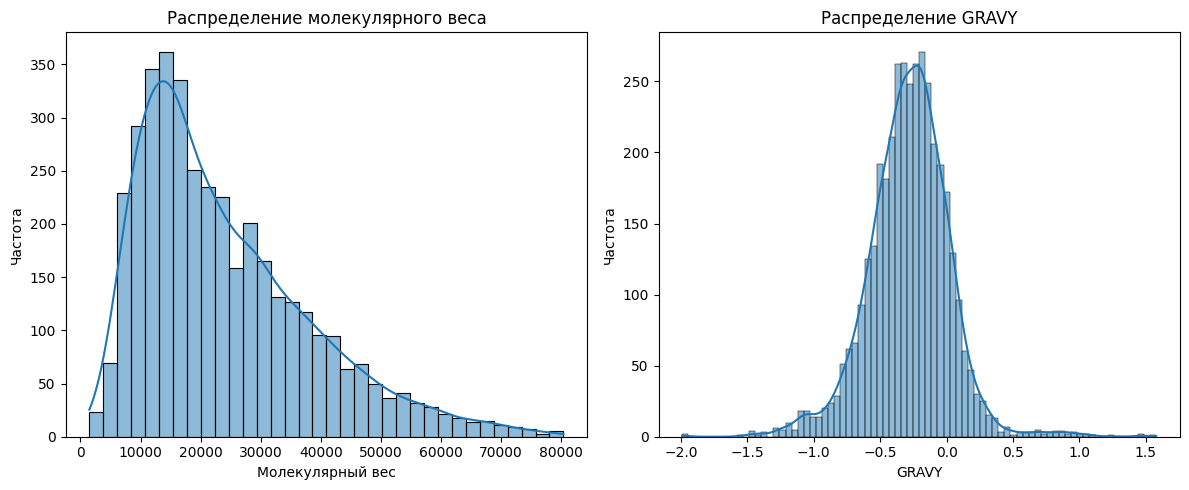

In [ ]:
# Визуализация признаков
sns.pairplot(df[['molecular_weight','gravy','aromaticity','target']], hue='target')
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['molecular_weight'], kde=True)
plt.title('Распределение молекулярного веса')
plt.xlabel('Молекулярный вес')
plt.ylabel('Частота')
plt.subplot(1, 2, 2)
sns.histplot(df['gravy'], kde=True)
plt.title('Распределение GRAVY')
plt.xlabel('GRAVY')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

In [ ]:
# Logistic Regression

log_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000, multi_class='auto'))
])

log_pipeline.fit(X_train_feat, y_train_feat)

pred_log = log_pipeline.predict(X_test_feat)
acc_log = accuracy_score(y_test_feat, pred_log)

print("Accuracy Logistic Regression:", acc_log)
print(classification_report(y_test_feat, pred_log))

Accuracy Logistic Regression: 0.5
              precision    recall  f1-score   support

           C       0.46      0.36      0.41       302
           E       0.00      0.00      0.00       105
           H       0.52      0.75      0.62       369

    accuracy                           0.50       776
   macro avg       0.33      0.37      0.34       776
weighted avg       0.43      0.50      0.45       776



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           C       0.50      0.47      0.49       302
           E       0.40      0.13      0.20       105
           H       0.58      0.72      0.64       369

    accuracy                           0.54       776
   macro avg       0.49      0.44      0.44       776
weighted avg       0.52      0.54      0.52       776



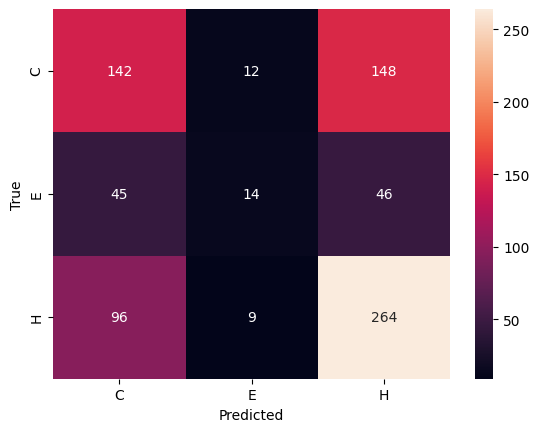

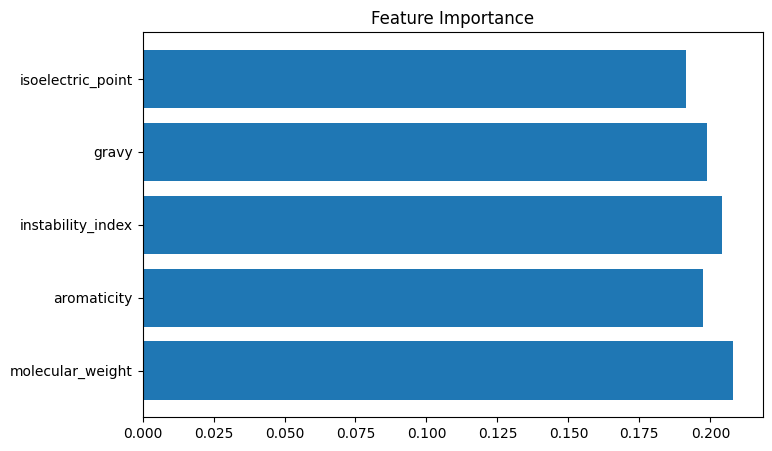

In [ ]:
#  Feature-based RandomForest
feature_columns = ['molecular_weight','aromaticity','instability_index','gravy','isoelectric_point']
X = df[feature_columns]
y = df['target']

X_train_feat, X_test_feat, y_train_feat, y_test_feat = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train_feat, y_train_feat)

pred_feat = model.predict(X_test_feat)
print(classification_report(y_test_feat, pred_feat))

# Confusion Matrix
cm = confusion_matrix(y_test_feat, pred_feat)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Feature Importance
importance = model.feature_importances_
plt.figure(figsize=(8,5))
plt.barh(feature_columns, importance)
plt.title("Feature Importance")
plt.show()


In [ ]:
# XGBOOST

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Encode target variable
le = LabelEncoder()
y_train_feat_encoded = le.fit_transform(y_train_feat)
y_test_feat_encoded = le.transform(y_test_feat)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train_feat, y_train_feat_encoded)

pred_xgb_encoded = xgb_model.predict(X_test_feat)
# Decode predictions back to original labels for consistent reporting
pred_xgb = le.inverse_transform(pred_xgb_encoded)

acc_xgb = accuracy_score(y_test_feat, pred_xgb)

print("Accuracy XGBoost:", acc_xgb)
print(classification_report(y_test_feat, pred_xgb))


Accuracy XGBoost: 0.5257731958762887
              precision    recall  f1-score   support

           C       0.48      0.49      0.48       302
           E       0.36      0.18      0.24       105
           H       0.58      0.66      0.62       369

    accuracy                           0.53       776
   macro avg       0.47      0.44      0.45       776
weighted avg       0.51      0.53      0.51       776



In [ ]:
# Моделирование мутаций
amino_acids = "ACDEFGHIKLMNPQRSTVWY"
def mutate(sequence):
    pos = random.randint(0, len(sequence)-1)
    new_aa = random.choice(amino_acids)
    return sequence[:pos] + new_aa + sequence[pos+1:]

original_seq = df.iloc[0]['seq']
mutated_seq = mutate(original_seq)
orig_features = protein_features(original_seq)
mut_features = protein_features(mutated_seq)

print("Original prediction:", model.predict([orig_features])[0])
print("Mutated prediction:", model.predict([mut_features])[0])

Original prediction: H
Mutated prediction: H


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# k-mer представление
def kmer_features(sequence, k=3):
    kmers = [sequence[i:i+k] for i in range(len(sequence)-k+1)]
    counts = Counter(kmers)
    total = sum(counts.values())
    for key in counts:
        counts[key] /= total
    return counts

k = 3
all_kmers = set()
for seq in df['seq'].head(5000):
    all_kmers.update(kmer_features(seq, k).keys())
all_kmers = list(all_kmers)
print("Количество k-mer:", len(all_kmers))

def vectorize_kmer(sequence):
    counts = kmer_features(sequence, k)
    return [counts.get(kmer, 0) for kmer in all_kmers]

X_kmer = np.array(df['seq'].head(5000).apply(vectorize_kmer).tolist())
y_kmer = df['target'].head(5000)

X_train_kmer, X_test_kmer, y_train_kmer, y_test_kmer = train_test_split(X_kmer, y_kmer, test_size=0.2, random_state=42)
model_kmer = RandomForestClassifier(n_estimators=100)
model_kmer.fit(X_train_kmer, y_train_kmer)

pred_kmer = model_kmer.predict(X_test_kmer)
print("Accuracy (k-mer):", model_kmer.score(X_test_kmer, y_test_kmer))


Количество k-mer: 7999
Accuracy (k-mer): 0.6443298969072165


In [ ]:
# Deep Learning Embeddings (ProtBERT)
tokenizer = AutoTokenizer.from_pretrained("Rostlab/prot_bert")
model_dl = AutoModel.from_pretrained("Rostlab/prot_bert")

def preprocess(seq):
    return " ".join(list(seq))

def get_embedding(sequence):
    sequence = preprocess(sequence)
    inputs = tokenizer(sequence, return_tensors="pt", padding=True, truncation=True)
    with torch.no_grad():
        outputs = model_dl(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze()
    return embedding.numpy()

subset = df.head(500)
X_embed = np.array(subset['seq'].apply(get_embedding).tolist())
y_embed = subset['target']

X_train_embed, X_test_embed, y_train_embed, y_test_embed = train_test_split(X_embed, y_embed, test_size=0.2, random_state=42)
model_embed = RandomForestClassifier(n_estimators=200)
model_embed.fit(X_train_embed, y_train_embed)

pred_embed = model_embed.predict(X_test_embed)
print("Accuracy (ProtBERT embeddings):", model_embed.score(X_test_embed, y_test_embed))

Loading weights:   0%|          | 0/487 [00:00<?, ?it/s]

BertModel LOAD REPORT from: Rostlab/prot_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Accuracy (ProtBERT embeddings): 0.67


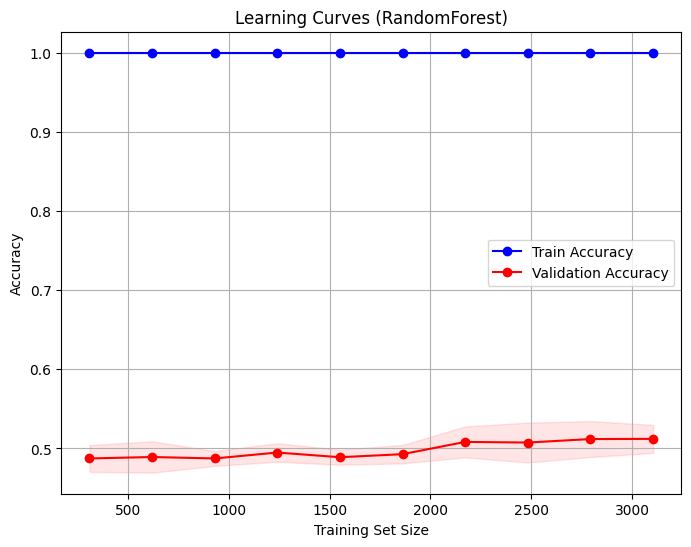

In [ ]:
# Learning Curves для RandomForest
n_splits = 5
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= n_splits].index
filtered_indices = y[y.isin(valid_classes)].index
X_filtered = X.loc[filtered_indices]
y_filtered = y.loc[filtered_indices]

cv = StratifiedKFold(n_splits=n_splits)
train_sizes, train_scores, test_scores = learning_curve(
    model, X_filtered, y_filtered, cv=cv, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Train Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', color='red', label='Validation Accuracy')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
plt.title('Learning Curves (RandomForest)')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.show()


In [ ]:
# Hyperparameter tuning через GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

rf_classifier = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf_classifier,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

X_filtered_final = X_filtered[y_filtered.isin(valid_classes)]
y_filtered_final = y_filtered[y_filtered.isin(valid_classes)]

grid_search.fit(X_filtered_final, y_filtered_final)
print("Best parameters found by GridSearchCV:", grid_search.best_params_)


Best parameters found by GridSearchCV: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}



Classification Report for Tuned RandomForestClassifier:
              precision    recall  f1-score   support

           C       0.80      0.79      0.80       302
           E       1.00      0.31      0.48       105
           H       0.76      0.91      0.83       369

    accuracy                           0.78       776
   macro avg       0.85      0.67      0.70       776
weighted avg       0.81      0.78      0.77       776



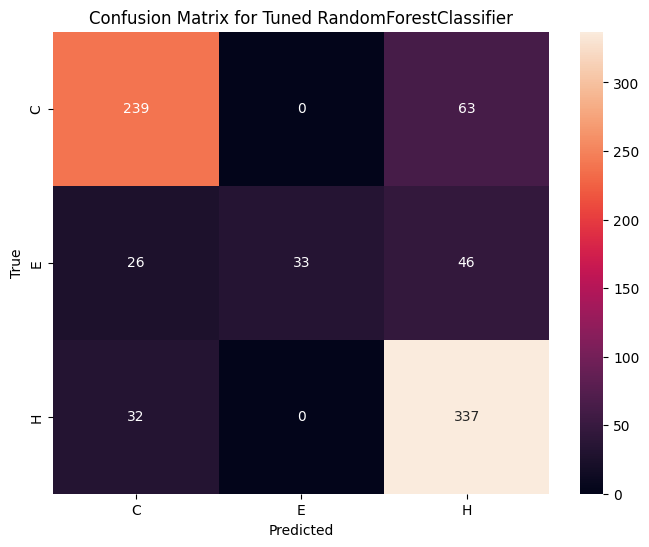

In [ ]:
# Обучение и оценка модели с оптимальными гиперпараметрами
best_rf_model = grid_search.best_estimator_

X_train_tuned, X_test_tuned, y_train_tuned, y_test_tuned = train_test_split(
    X_filtered_final, y_filtered_final, test_size=0.2, random_state=42, stratify=y_filtered_final
)

pred_tuned = best_rf_model.predict(X_test_tuned)
print("\nClassification Report for Tuned RandomForestClassifier:")
print(classification_report(y_test_tuned, pred_tuned))

cm_tuned = confusion_matrix(y_test_tuned, pred_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', xticklabels=best_rf_model.classes_,
            yticklabels=best_rf_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Tuned RandomForestClassifier")
plt.show()


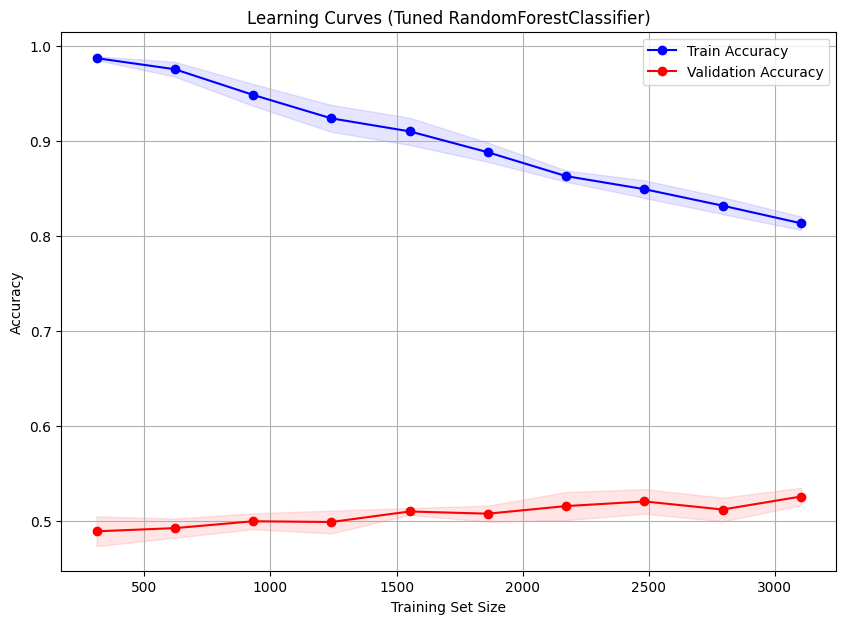

In [ ]:
# Learning Curves для оптимизированной модели
train_sizes, train_scores, test_scores = learning_curve(
    best_rf_model, X_filtered_final, y_filtered_final,
    cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42),
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 7))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Train Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', color='red', label='Validation Accuracy')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
plt.title('Learning Curves (Tuned RandomForestClassifier)')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.show()

                                Model  Accuracy
0                  Tuned RandomForest  0.784794
1  RandomForest (ProtBERT embeddings)  0.670000
2                RandomForest (k-mer)  0.644330
3             RandomForest (features)  0.541237
4                             XGBoost  0.525773
5                 Logistic Regression  0.500000


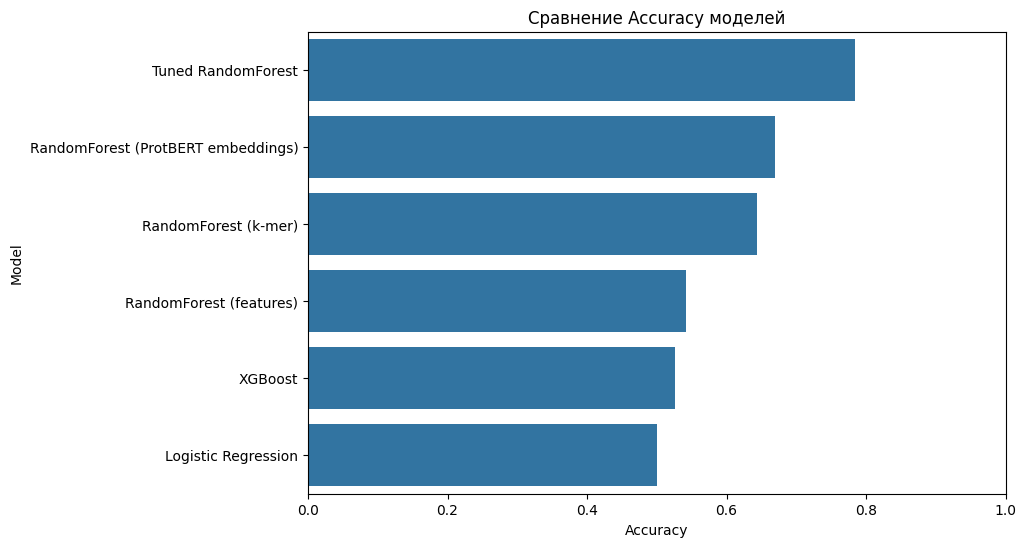

In [ ]:
# Сводная таблица Accuracy всех моделей
from sklearn.metrics import accuracy_score

# 1. Feature-based RandomForest
acc_feature_rf = accuracy_score(y_test_feat, pred_feat)

# 2. k-mer RandomForest
acc_kmer_rf = accuracy_score(y_test_kmer, pred_kmer)

# 3. ProtBERT embeddings RandomForest
acc_embed_rf = accuracy_score(y_test_embed, pred_embed)

# 4. Tuned RandomForest
acc_tuned_rf = accuracy_score(y_test_tuned, pred_tuned)

# Создаем DataFrame для наглядности
acc_df = pd.DataFrame({
    'Model': [
        'RandomForest (features)',
        'RandomForest (k-mer)',
        'RandomForest (ProtBERT embeddings)',
        'Tuned RandomForest',
        'Logistic Regression',
        'XGBoost'
    ],
    'Accuracy': [
        acc_feature_rf,
        acc_kmer_rf,
        acc_embed_rf,
        acc_tuned_rf,
        acc_log,
        acc_xgb
    ]
})

acc_df = acc_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print(acc_df)

plt.figure(figsize=(9,6))
sns.barplot(x='Accuracy', y='Model', data=acc_df)
plt.xlim(0,1)
plt.title('Сравнение Accuracy моделей')
plt.show()

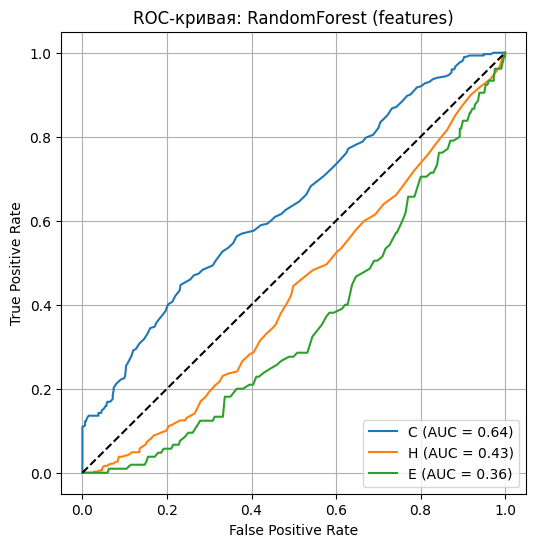

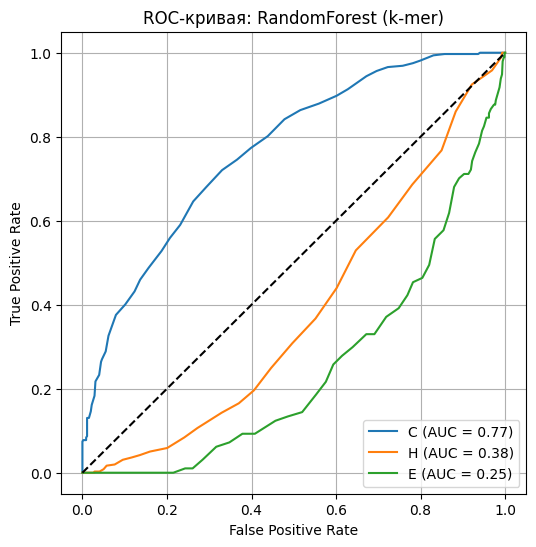

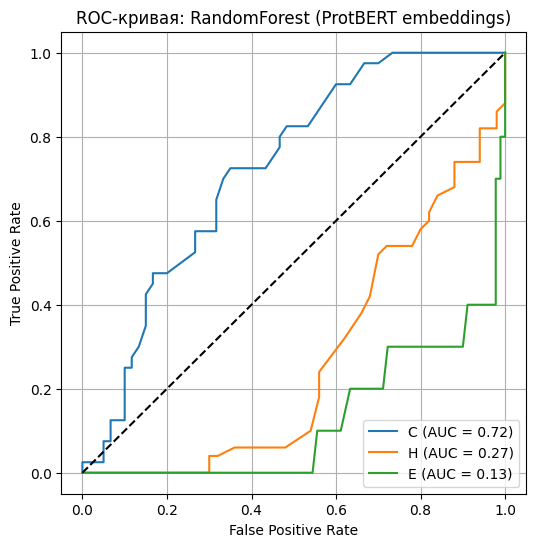

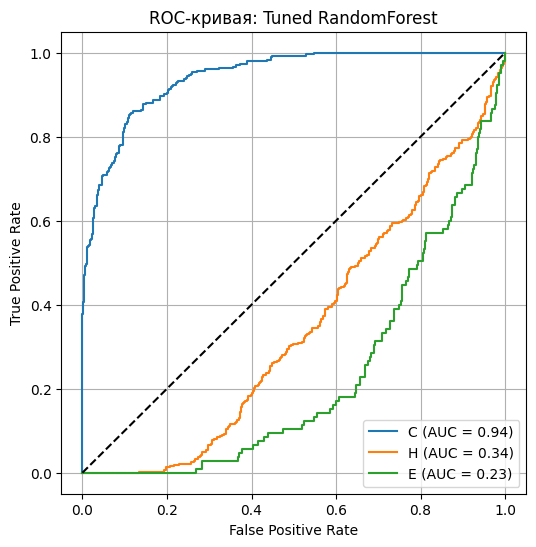

In [ ]:
# ROC-кривые для всех моделей

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Классы
classes = ['C', 'H', 'E']

# Функция для построения ROC
def plot_roc_curve(y_true, y_score, model_name):
    y_true_bin = label_binarize(y_true, classes=classes)
    plt.figure(figsize=(6,6))
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.title(f'ROC-кривая: {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

# 1. Feature-based RandomForest
y_score_feature = model.predict_proba(X_test_feat)
plot_roc_curve(y_test_feat, y_score_feature, 'RandomForest (features)')

# 2. k-mer RandomForest
y_score_kmer = model_kmer.predict_proba(X_test_kmer)
plot_roc_curve(y_test_kmer, y_score_kmer, 'RandomForest (k-mer)')

# 3. ProtBERT embeddings RandomForest
y_score_embed = model_embed.predict_proba(X_test_embed)
plot_roc_curve(y_test_embed, y_score_embed, 'RandomForest (ProtBERT embeddings)')

# 4. Tuned RandomForest
y_score_tuned = best_rf_model.predict_proba(X_test_tuned)
plot_roc_curve(y_test_tuned, y_score_tuned, 'Tuned RandomForest')
